### INSTALLATIONS ET IMPORTS

In [5]:
!pip install pymongo

import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import gc
import pymongo
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_score, recall_score, f1_score
from transformers import BertTokenizer, BertModel
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW

# Configuration Matérielle
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Appareil utilisé : {device}")

# Initialisation du tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 38.9 MB/s eta 0:00:00
Appareil utilisé : cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

PRÉPARATION DE LA DATA

In [6]:
class SocialMediaDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=100):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]

        encoding = self.tokenizer(
            text, add_special_tokens=True, max_length=self.max_len,
            padding='max_length', truncation=True,
            return_attention_mask=True, return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Fonction de chargement depuis les fichiers CSV générés par MongoDB
def load_data_from_csv(source_name=None, sample_per_class=None): # paramètre laissé pour compatibilité
    filename = f"dataset_{source_name}.csv" if source_name else "dataset_global.csv"
    print(f"\n[Cloud] Chargement des données pré-extraites : {filename}")

    try:
        df = pd.read_csv(filename)
        print(f"[Cloud] Taille du dataset chargé : {len(df)} commentaires.")
        return df
    except FileNotFoundError:
        print(f"fichier {filename} non trouvé.")
        return None

def prepare_loaders(df, tokenizer, batch_size=32):
    total_lignes = len(df)

    # Règle stricte : 6400 pour le test (si le dataset est assez grand)
    if total_lignes >= 38400:
        test_size_exact = 6400
    else:
        # Pour Social Mixed (qui n'a que 3378 lignes), on garde la même proportion (1/6ème)
        test_size_exact = int(total_lignes * (6400 / 38400))

    # Séparation stricte et équilibrée avec stratify
    train_df, test_df = train_test_split(
        df,
        test_size=test_size_exact,
        random_state=42,
        stratify=df['label']
    )

    print(f"[Split] Train: {len(train_df)} | Test: {len(test_df)} | Total: {total_lignes}")

    # Création des Datasets
    train_dataset = SocialMediaDataset(train_df['text'].to_numpy(), train_df['label'].to_numpy(), tokenizer)
    test_dataset = SocialMediaDataset(test_df['text'].to_numpy(), test_df['label'].to_numpy(), tokenizer)

    # Création des DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    # On retourne le test_loader 2 fois pour remplacer le val_loader (évaluation directe)
    return train_loader, test_loader, test_loader

ANALYSE EXPLORATOIRE (TOP DES MOTS)

Génération des graphiques du Top 10 des mots en cours...


/tmp/ipykernel_4413/2933752501.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, y='Word', x='Frequency', ax=axes[i], palette='viridis')
/tmp/ipykernel_4413/2933752501.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, y='Word', x='Frequency', ax=axes[i], palette='viridis')
/tmp/ipykernel_4413/2933752501.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, y='Word', x='Frequency', ax=axes[i], palette='viridis')
/tmp/ipykernel_4413/2933752501.py:35: FutureWarning: 

Passing `palette` without assigni

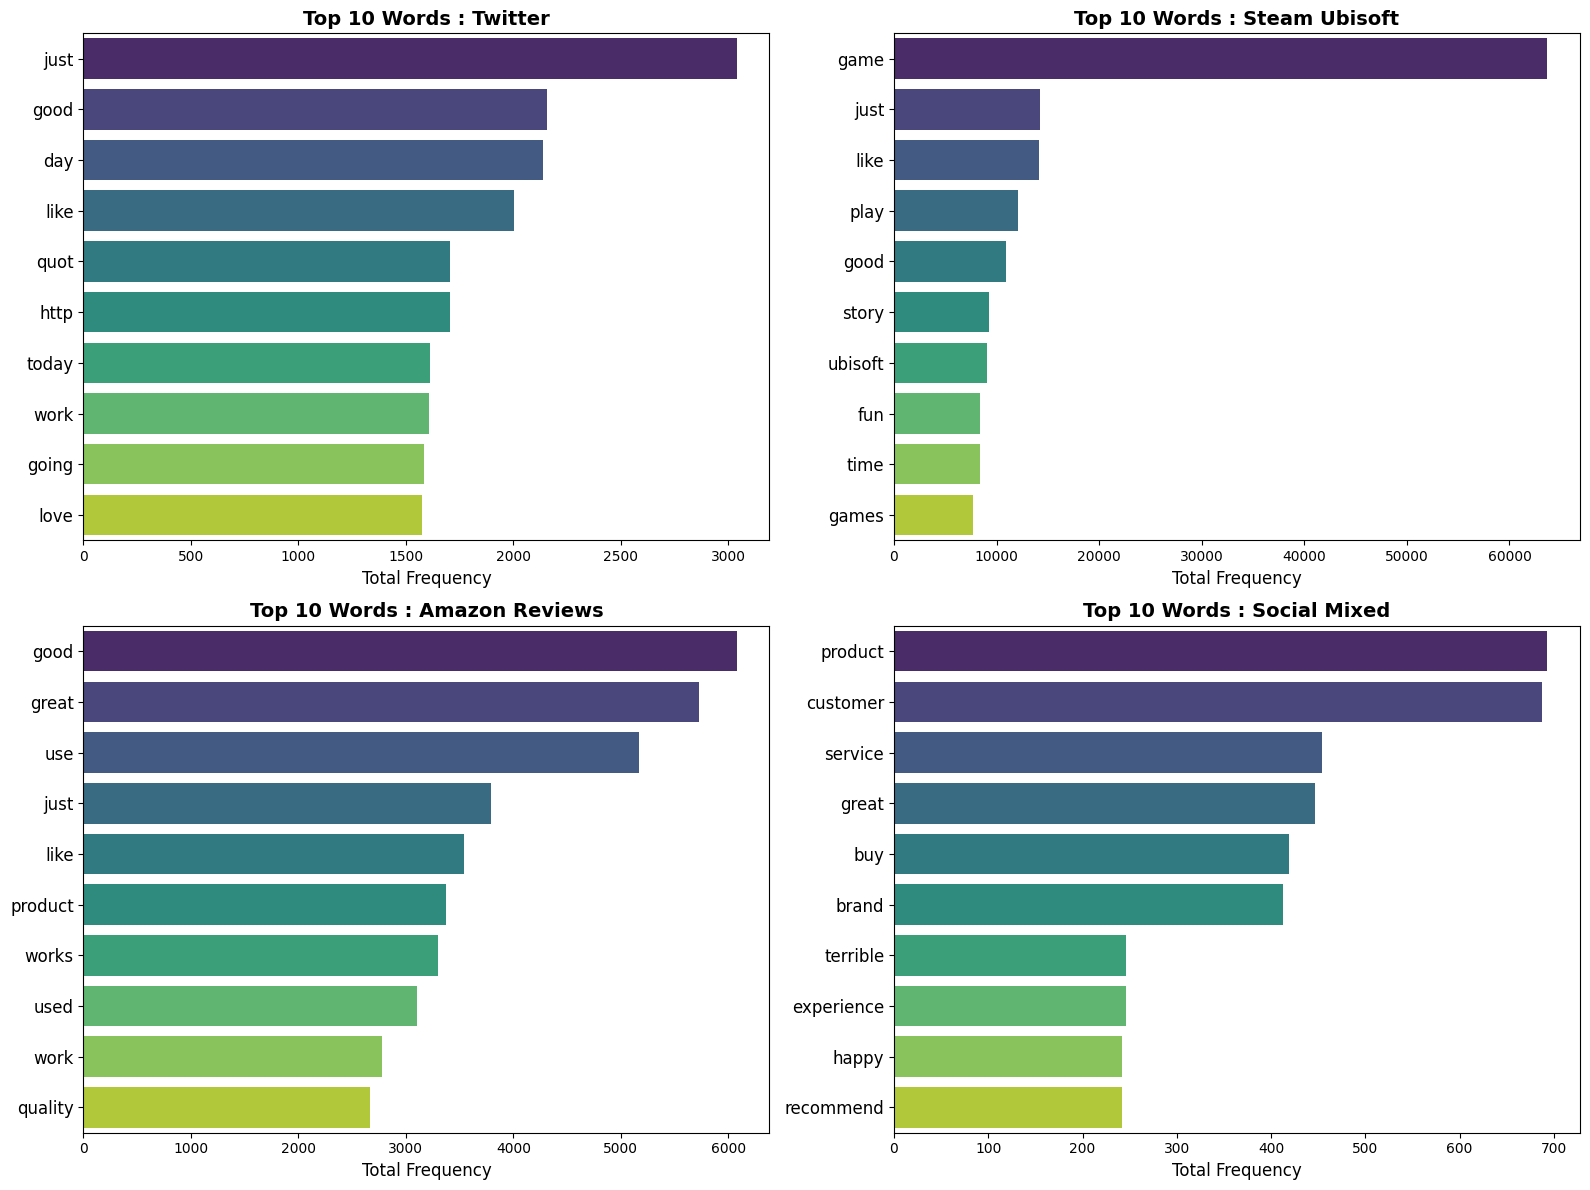

In [7]:
from sklearn.feature_extraction.text import CountVectorizer

# Définition des sources
sources = ['twitter', 'steam_ubisoft', 'amazon_reviews', 'social_mixed']

# Création de la grande figure (Grille 2x2)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Mots vides (stop words) personnalisés pour nettoyer le bruit du web
# On utilise l'anglais de base, et on rajoute des mots parasites courants
custom_stop_words = list(CountVectorizer(stop_words='english').get_stop_words())

print("Génération des graphiques du Top 10 des mots en cours...")

for i, source in enumerate(sources):
    filename = f"dataset_{source}.csv"
    try:
        # On charge uniquement la colonne 'text' pour économiser la RAM
        df = pd.read_csv(filename, usecols=['text'])
        texts = df['text'].dropna().astype(str)

        # Le Vectorizer compte chaque mot en ignorant la ponctuation et les stop words
        vec = CountVectorizer(stop_words=custom_stop_words, max_features=10)
        word_matrix = vec.fit_transform(texts)

        # Calcul des fréquences totales
        word_counts = word_matrix.sum(axis=0).A1
        words = vec.get_feature_names_out()

        # Tri du Top 10
        top_10 = pd.DataFrame({'Word': words, 'Frequency': word_counts}).sort_values(by='Frequency', ascending=False)

        # Création du graphique horizontal
        sns.barplot(data=top_10, y='Word', x='Frequency', ax=axes[i], palette='viridis')

        # Esthétique du graphique
        titre = source.replace("_", " ").title()
        axes[i].set_title(f'Top 10 Words : {titre}', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Total Frequency', fontsize=12)
        axes[i].set_ylabel('')
        axes[i].tick_params(axis='y', labelsize=12)

    except FileNotFoundError:
        axes[i].set_title(f'Fichier {filename} introuvable', color='red')
        axes[i].axis('off')

# Ajustement pour que rien ne se chevauche
plt.tight_layout()
plt.show()

### Model Architecture: BERT-BiLSTM-Attention

The `MDMLSM_Solution` model implements a powerful hybrid architecture for text classification. It is designed to capture both the deep meaning of words and their global context. It consists of three main stages:

1. **Contextual Encoder (BERT)**: Uses a `bert-base-multilingual-cased` model with full fine-tuning. It extracts rich vector representations (768 dimensions) for each word based on its immediate context.
2. **Sequential Modeling (BiLSTM)**: A bidirectional LSTM layer processes the BERT outputs in both directions (past and future) to capture the dynamics and long-term dependencies of the entire sentence.
3. **Attention Mechanism & Classifier**: Instead of treating all words equally, an attention layer calculates an importance score for each word. These words are combined into a weighted "context vector", which undergoes a regularization step (30% Dropout) before being classified into one of the 2 final classes.

In [8]:
# ==========================================
# ARCHITECTURE DU MODÈLE
# ==========================================

class MDMLSM_Solution(nn.Module):
    def __init__(self):
        super(MDMLSM_Solution, self).__init__()
        self.bert = BertModel.from_pretrained('bert-base-multilingual-cased')

        # Déclenche l'entraînement de tous les paramètres BERT (Fine-tuning total)
        for param in self.bert.parameters():
            param.requires_grad = True

        # LSTM Bidirectionnelle pour capturer le contexte séquentiel (768 -> 128x2)
        self.lstm = nn.LSTM(input_size=768, hidden_size=128, num_layers=1, batch_first=True, bidirectional=True)

        # Couche pour calculer les scores d'attention sur les sorties du LSTM
        self.attention_weights = nn.Linear(128 * 2, 1)

        # Classifieur final (2 classes en sortie)
        self.classifier = nn.Linear(128 * 2, 2)
        self.dropout = nn.Dropout(0.3)

    def forward(self, input_ids, attention_mask):
        # Extraction des embeddings contextuels via BERT
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = bert_out.last_hidden_state

        # Passage dans la LSTM (conserve toute la séquence)
        lstm_out, _ = self.lstm(sequence_output)

        # Mécanisme d'Attention : pondère l'importance de chaque mot
        attn_score = self.attention_weights(lstm_out)
        attn_dist = torch.softmax(attn_score, dim=1)

        # Agrégation : somme pondérée pour obtenir un vecteur fixe (Context Vector)
        context_vector = torch.sum(attn_dist * lstm_out, dim=1)

        # Régularisation et Classification finale
        out = self.dropout(context_vector)
        return self.classifier(out)

FONCTIONS D'ENTRAÎNEMENT ET D'ÉVALUATION

In [9]:
def train_model(train_loader, val_loader, epochs=2):
    model = MDMLSM_Solution().to(device)
    optimizer = AdamW(model.parameters(), lr=2e-5)
    loss_fn = nn.CrossEntropyLoss()

    print("\nDémarrage de l'entraînement...")
    for epoch in range(epochs):
        model.train()
        total_loss, correct_predictions, total_samples = 0, 0, 0

        for step, batch in enumerate(train_loader):
            input_ids, mask, labels = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['labels'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, mask)
            loss = loss_fn(outputs, labels)

            _, preds = torch.max(outputs, dim=1)
            correct_predictions += torch.sum(preds == labels)
            total_samples += labels.size(0)

            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_acc = correct_predictions.double() / total_samples
        print(f"Fin Époque {epoch + 1}/{epochs} - Loss: {total_loss / len(train_loader):.4f} - Accuracy: {avg_acc:.4f}")

    return model

def evaluate_model(model, test_loader, title="Dataset"):
    model.eval()
    predictions, real_values, probabilities = [], [], []
    with torch.no_grad():
        for batch in test_loader:
            outputs = model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
            _, preds = torch.max(outputs, dim=1)
            predictions.extend(preds.cpu().tolist())
            real_values.extend(batch['labels'].to(device).cpu().tolist())
            probabilities.extend(torch.softmax(outputs, dim=1)[:, 1].cpu().tolist())

    # Calcul de TOUTES les métriques Big Data
    acc = accuracy_score(real_values, predictions)
    auc = roc_auc_score(real_values, probabilities)
    prec = precision_score(real_values, predictions)
    rec = recall_score(real_values, predictions)
    f1 = f1_score(real_values, predictions)

    print(f"\n" + "="*40)
    print(f"RÉSULTATS : {title}")
    print("="*40)
    print(f"Accuracy : {acc:.4f} (Précision globale)")
    print(f"AUC : {auc:.4f} (Aire sous la courbe ROC)")
    print(f"Precision : {prec:.4f} (Pertinence des prédictions positives)")
    print(f"Recall : {rec:.4f} (Capacité à trouver tous les vrais positifs)")
    print(f"F1-Score : {f1:.4f} (Moyenne harmonique Precision/Recall)")
    print("-" * 40)
    print(classification_report(real_values, predictions, target_names=['Négatif', 'Positif']))

    return real_values, predictions, probabilities

def plot_metrics(y_true, y_pred, y_probs, title="Modèle"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Matrice de Confusion
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'], ax=ax1)
    ax1.set_title(f'Matrice de Confusion ({title})')
    ax1.set_xlabel('Prédiction')
    ax1.set_ylabel('Réel')

    # 2. Courbe ROC
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    auc_score = roc_auc_score(y_true, y_probs)
    ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {auc_score:.3f})')
    ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel('Taux de Faux Positifs (FPR)')
    ax2.set_ylabel('Taux de Vrais Positifs (TPR)')
    ax2.set_title(f'Courbe ROC ({title})')
    ax2.legend(loc="lower right")

    plt.tight_layout()
    plt.show()

EXÉCUTION DES 5 DATASETS


SCÉNARIO 1 : TOUTES LES DONNÉES (DATA GLOBAL)

[Cloud] Chargement des données pré-extraites : dataset_global.csv
[Cloud] Taille du dataset chargé : 38400 commentaires.
[Split] Train: 32000 | Test: 6400 | Total: 38400


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Démarrage de l'entraînement...
Fin Époque 1/2 - Loss: 0.4837 - Accuracy: 0.7663
Fin Époque 2/2 - Loss: 0.3671 - Accuracy: 0.8389

RÉSULTATS : Global (Toutes Sources)
Accuracy : 0.8105 (Précision globale)
AUC : 0.9044 (Aire sous la courbe ROC)
Precision : 0.7636 (Pertinence des prédictions positives)
Recall : 0.8994 (Capacité à trouver tous les vrais positifs)
F1-Score : 0.8259 (Moyenne harmonique Precision/Recall)
----------------------------------------
              precision    recall  f1-score   support

     Négatif       0.88      0.72      0.79      3200
     Positif       0.76      0.90      0.83      3200

    accuracy                           0.81      6400
   macro avg       0.82      0.81      0.81      6400
weighted avg       0.82      0.81      0.81      6400



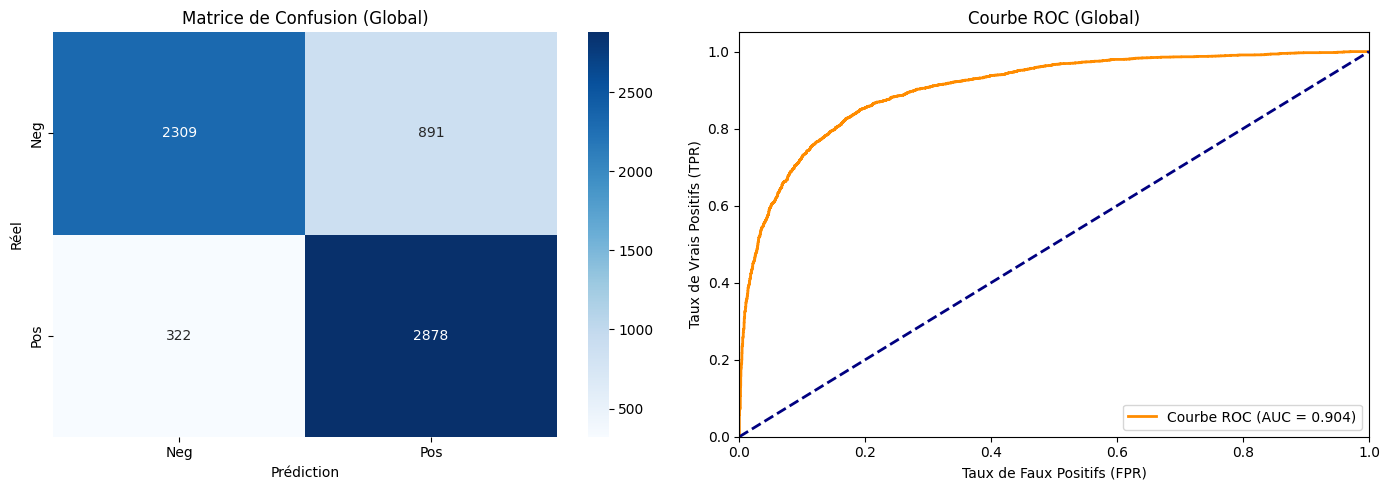

In [10]:
# --- SCÉNARIO 1 : DATASET GLOBAL ---
print("\n" + "="*50)
print("SCÉNARIO 1 : TOUTES LES DONNÉES (DATA GLOBAL)")
print("="*50)
df_global = load_data_from_csv(source_name=None)

if df_global is not None:
    train_loader, val_loader, test_loader = prepare_loaders(df_global, tokenizer)
    model_global = train_model(train_loader, val_loader, epochs=2)

    # Évaluation globale avec toutes les métriques
    y_true_glob, y_pred_glob, y_probs_glob = evaluate_model(model_global, test_loader, title="Global (Toutes Sources)")
    plot_metrics(y_true_glob, y_pred_glob, y_probs_glob, title="Global")

# Nettoyage mémoire RAM & GPU
del df_global, train_loader, val_loader, test_loader
gc.collect()
torch.cuda.empty_cache()


SCÉNARIO 2 : SOURCE TWITTER

[Cloud] Chargement des données pré-extraites : dataset_twitter.csv
[Cloud] Taille du dataset chargé : 38400 commentaires.
[Split] Train: 32000 | Test: 6400 | Total: 38400


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Démarrage de l'entraînement...
Fin Époque 1/2 - Loss: 0.4899 - Accuracy: 0.7622
Fin Époque 2/2 - Loss: 0.3744 - Accuracy: 0.8372

RÉSULTATS : Twitter
Accuracy : 0.8163 (Précision globale)
AUC : 0.8963 (Aire sous la courbe ROC)
Precision : 0.8089 (Pertinence des prédictions positives)
Recall : 0.8281 (Capacité à trouver tous les vrais positifs)
F1-Score : 0.8184 (Moyenne harmonique Precision/Recall)
----------------------------------------
              precision    recall  f1-score   support

     Négatif       0.82      0.80      0.81      3200
     Positif       0.81      0.83      0.82      3200

    accuracy                           0.82      6400
   macro avg       0.82      0.82      0.82      6400
weighted avg       0.82      0.82      0.82      6400



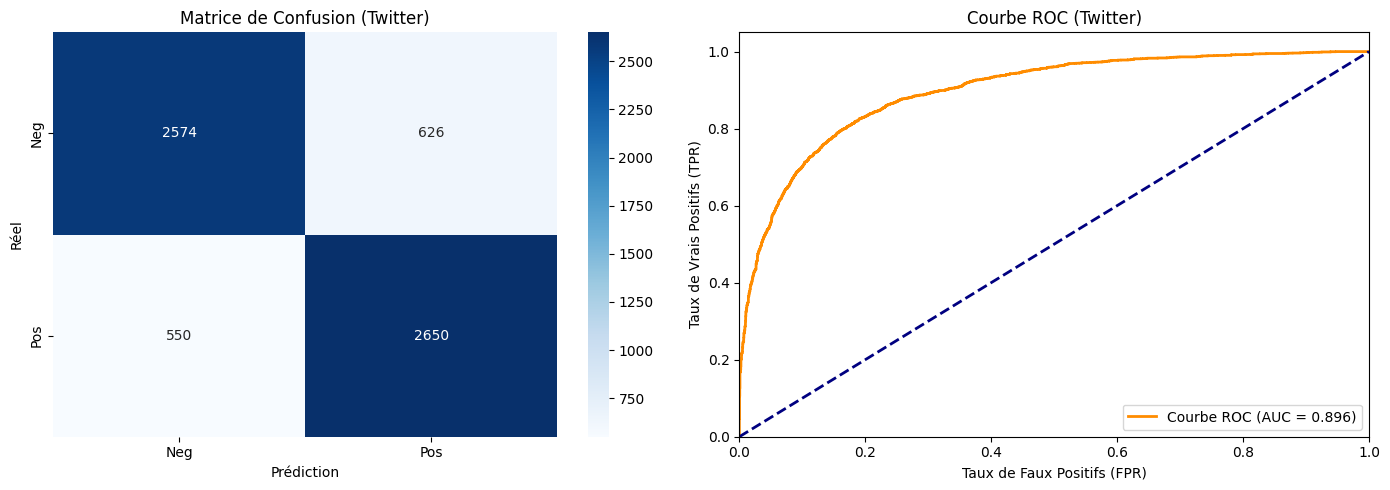

In [6]:
# --- SCÉNARIO 2 : SOURCE TWITTER ---
print("\n" + "="*50)
print("SCÉNARIO 2 : SOURCE TWITTER")
print("="*50)
df_twitter = load_data_from_csv(source_name="twitter")

if df_twitter is not None:
    train_loader, val_loader, test_loader = prepare_loaders(df_twitter, tokenizer)
    model_twitter = train_model(train_loader, val_loader, epochs=2)
    y_true, y_pred, y_probs = evaluate_model(model_twitter, test_loader, title="Twitter")
    plot_metrics(y_true, y_pred, y_probs, title="Twitter")

del df_twitter, train_loader, val_loader, test_loader
gc.collect()
torch.cuda.empty_cache()


SCÉNARIO 3 : SOURCE STEAM (JEUX VIDÉO)

[Cloud] Chargement des données pré-extraites : dataset_steam_ubisoft.csv
[Cloud] Taille du dataset chargé : 38400 commentaires.
[Split] Train: 32000 | Test: 6400 | Total: 38400


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Démarrage de l'entraînement...
Fin Époque 1/2 - Loss: 0.3808 - Accuracy: 0.8307
Fin Époque 2/2 - Loss: 0.2736 - Accuracy: 0.8872

RÉSULTATS : Steam
Accuracy : 0.8612 (Précision globale)
AUC : 0.9434 (Aire sous la courbe ROC)
Precision : 0.9241 (Pertinence des prédictions positives)
Recall : 0.7872 (Capacité à trouver tous les vrais positifs)
F1-Score : 0.8502 (Moyenne harmonique Precision/Recall)
----------------------------------------
              precision    recall  f1-score   support

     Négatif       0.81      0.94      0.87      3200
     Positif       0.92      0.79      0.85      3200

    accuracy                           0.86      6400
   macro avg       0.87      0.86      0.86      6400
weighted avg       0.87      0.86      0.86      6400



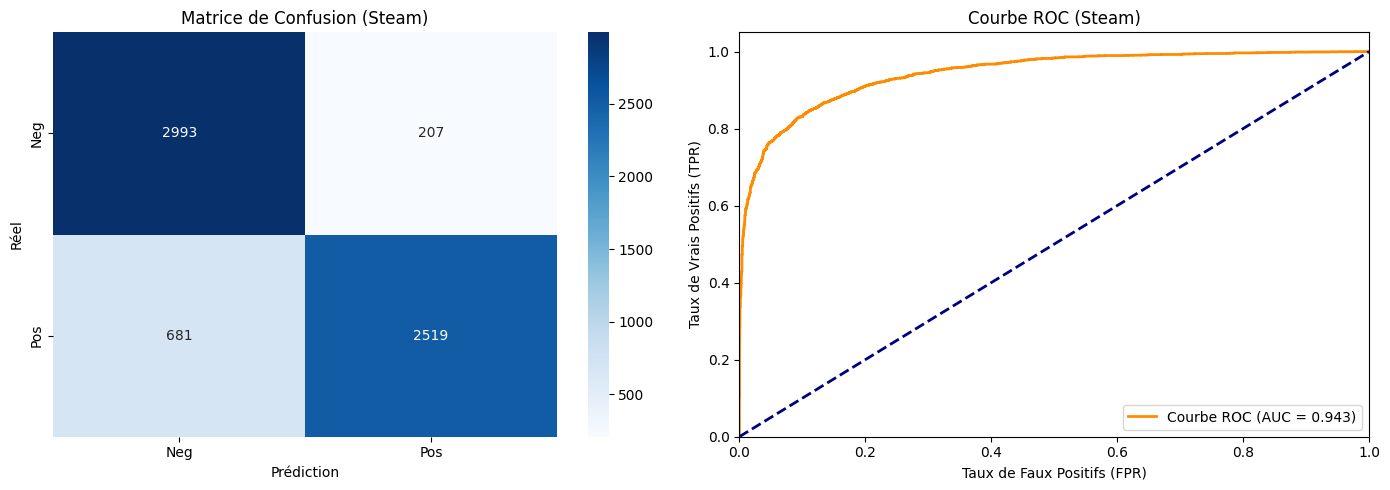

In [7]:
# --- SCÉNARIO 3 : SOURCE STEAM (JEUX VIDÉO) ---
print("\n" + "="*50)
print("SCÉNARIO 3 : SOURCE STEAM (JEUX VIDÉO)")
print("="*50)
df_steam = load_data_from_csv(source_name="steam_ubisoft")

if df_steam is not None:
    train_loader, val_loader, test_loader = prepare_loaders(df_steam, tokenizer)
    model_steam = train_model(train_loader, val_loader, epochs=2)
    y_true, y_pred, y_probs = evaluate_model(model_steam, test_loader, title="Steam")
    plot_metrics(y_true, y_pred, y_probs, title="Steam")

del df_steam, train_loader, val_loader, test_loader
gc.collect()
torch.cuda.empty_cache()


SCÉNARIO 4 : SOURCE AMAZON

[Cloud] Chargement des données pré-extraites : dataset_amazon_reviews.csv
[Cloud] Taille du dataset chargé : 23334 commentaires.
[Split] Train: 19445 | Test: 3889 | Total: 23334


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Démarrage de l'entraînement...
Fin Époque 1/2 - Loss: 0.2313 - Accuracy: 0.9041
Fin Époque 2/2 - Loss: 0.1294 - Accuracy: 0.9497

RÉSULTATS : Amazon
Accuracy : 0.9419 (Précision globale)
AUC : 0.9762 (Aire sous la courbe ROC)
Precision : 0.9492 (Pertinence des prédictions positives)
Recall : 0.9819 (Capacité à trouver tous les vrais positifs)
F1-Score : 0.9653 (Moyenne harmonique Precision/Recall)
----------------------------------------
              precision    recall  f1-score   support

     Négatif       0.90      0.76      0.82       689
     Positif       0.95      0.98      0.97      3200

    accuracy                           0.94      3889
   macro avg       0.92      0.87      0.89      3889
weighted avg       0.94      0.94      0.94      3889



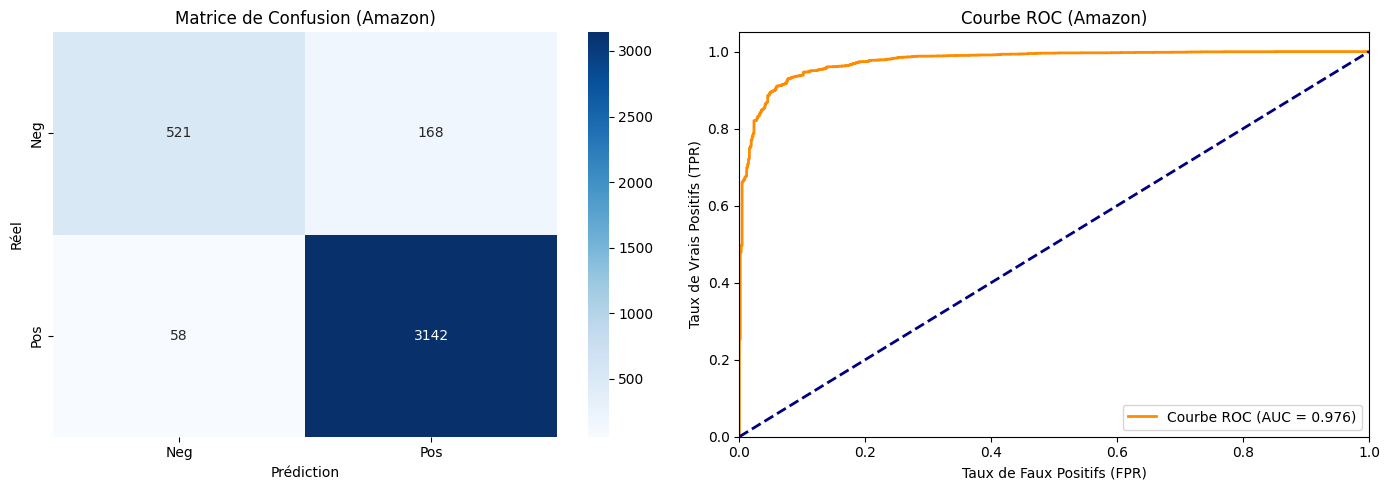

In [8]:
# --- SCÉNARIO 4 : SOURCE AMAZON ---
print("\n" + "="*50)
print("SCÉNARIO 4 : SOURCE AMAZON")
print("="*50)
df_amazon = load_data_from_csv(source_name="amazon_reviews")

if df_amazon is not None:
    train_loader, val_loader, test_loader = prepare_loaders(df_amazon, tokenizer)
    model_amazon = train_model(train_loader, val_loader, epochs=2)
    y_true, y_pred, y_probs = evaluate_model(model_amazon, test_loader, title="Amazon")
    plot_metrics(y_true, y_pred, y_probs, title="Amazon")

del df_amazon, train_loader, val_loader, test_loader
gc.collect()
torch.cuda.empty_cache()


SCÉNARIO 5 : SOURCE SOCIAL_MIXED

[Cloud] Chargement des données pré-extraites : dataset_social_mixed.csv
[Cloud] Taille du dataset chargé : 3378 commentaires.
[Split] Train: 2815 | Test: 563 | Total: 3378


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Démarrage de l'entraînement...
Fin Époque 1/2 - Loss: 0.7018 - Accuracy: 0.4924
Fin Époque 2/2 - Loss: 0.6951 - Accuracy: 0.5083

RÉSULTATS : Social Mixed
Accuracy : 0.5329 (Précision globale)
AUC : 0.5255 (Aire sous la courbe ROC)
Precision : 0.5502 (Pertinence des prédictions positives)
Recall : 0.5103 (Capacité à trouver tous les vrais positifs)
F1-Score : 0.5295 (Moyenne harmonique Precision/Recall)
----------------------------------------
              precision    recall  f1-score   support

     Négatif       0.52      0.56      0.54       273
     Positif       0.55      0.51      0.53       290

    accuracy                           0.53       563
   macro avg       0.53      0.53      0.53       563
weighted avg       0.53      0.53      0.53       563



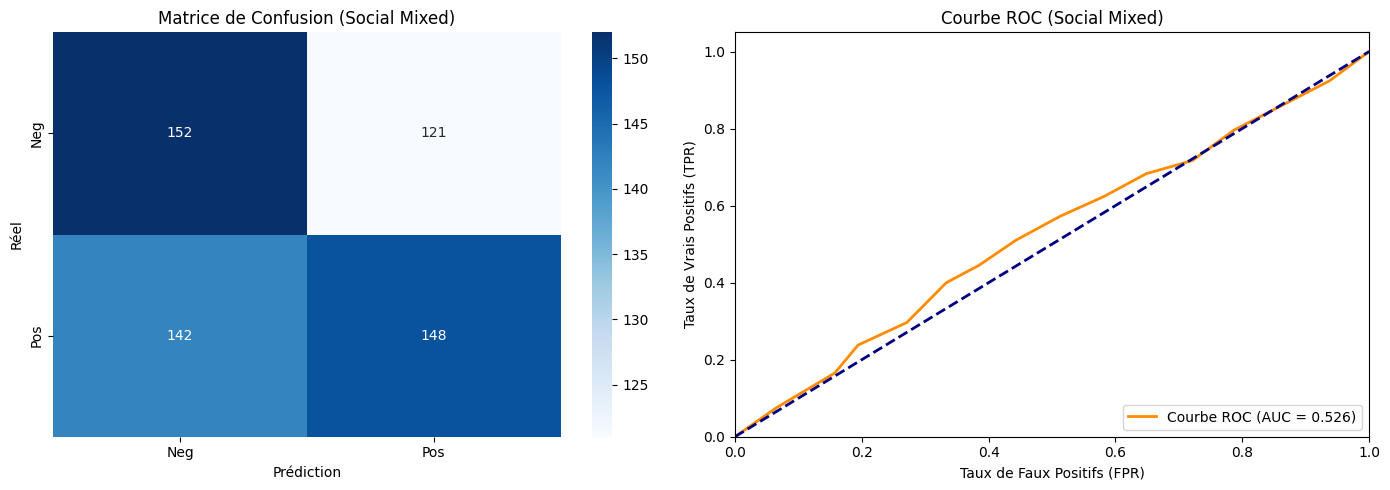

In [9]:
# --- SCÉNARIO 5 : SOURCE SOCIAL_MIXED ---
print("\n" + "="*50)
print("SCÉNARIO 5 : SOURCE SOCIAL_MIXED")
print("="*50)
df_social = load_data_from_csv(source_name="social_mixed")

if df_social is not None:
    train_loader, val_loader, test_loader = prepare_loaders(df_social, tokenizer)
    model_social = train_model(train_loader, val_loader, epochs=2)
    y_true, y_pred, y_probs = evaluate_model(model_social, test_loader, title="Social Mixed")
    plot_metrics(y_true, y_pred, y_probs, title="Social Mixed")

del df_social, train_loader, val_loader, test_loader
gc.collect()
torch.cuda.empty_cache()

TESTS CONSOLE

In [12]:
# On utilise ici le 'model_global' qui a été entraîné sur toutes les données.

def predict(text, model):
    encoded = tokenizer(text, max_length=100, padding='max_length', truncation=True, return_tensors='pt')
    model.eval()
    with torch.no_grad():
        output = model(encoded['input_ids'].to(device), encoded['attention_mask'].to(device))
        _, pred = torch.max(output, dim=1)
        prob = torch.softmax(output, dim=1)[0][pred].item()

    # Labels simplifiés sans emoji
    label = "POSITIF" if pred.item() == 1 else "NEGATIF"
    return f"Comment: '{text}' \n--> {label} (Confidence: {prob:.2f})\n"

print("="*50 + "\nTESTS DIRECT (avec le modèle global)\n" + "="*50)

try:
    # 5 nouveaux tests exclusivement en anglais
    print(predict("This is absolutely amazing, I love your work!", model_global))
    print(predict("Waste of time, the quality is very poor.", model_global))
    print(predict("I was expecting much more from this brand.", model_global))
    print(predict("Incredible experience, will definitely come back soon!", model_global))
    print(predict("The service was rude and the place was dirty.", model_global))
except NameError:
    print("Erreur: 'model_global' non trouvé")

TESTS DIRECT (avec le modèle global)
Comment: 'This is absolutely amazing, I love your work!' 
--> POSITIF (Confidence: 0.99)

Comment: 'Waste of time, the quality is very poor.' 
--> NEGATIF (Confidence: 0.89)

Comment: 'I was expecting much more from this brand.' 
--> NEGATIF (Confidence: 0.50)

Comment: 'Incredible experience, will definitely come back soon!' 
--> POSITIF (Confidence: 0.90)

Comment: 'The service was rude and the place was dirty.' 
--> NEGATIF (Confidence: 0.95)



### EXPLORATORY DATA ANALYSIS (GLOBAL WORD CLOUD)

Generated with ChatGPT

Generating Global Word Cloud...


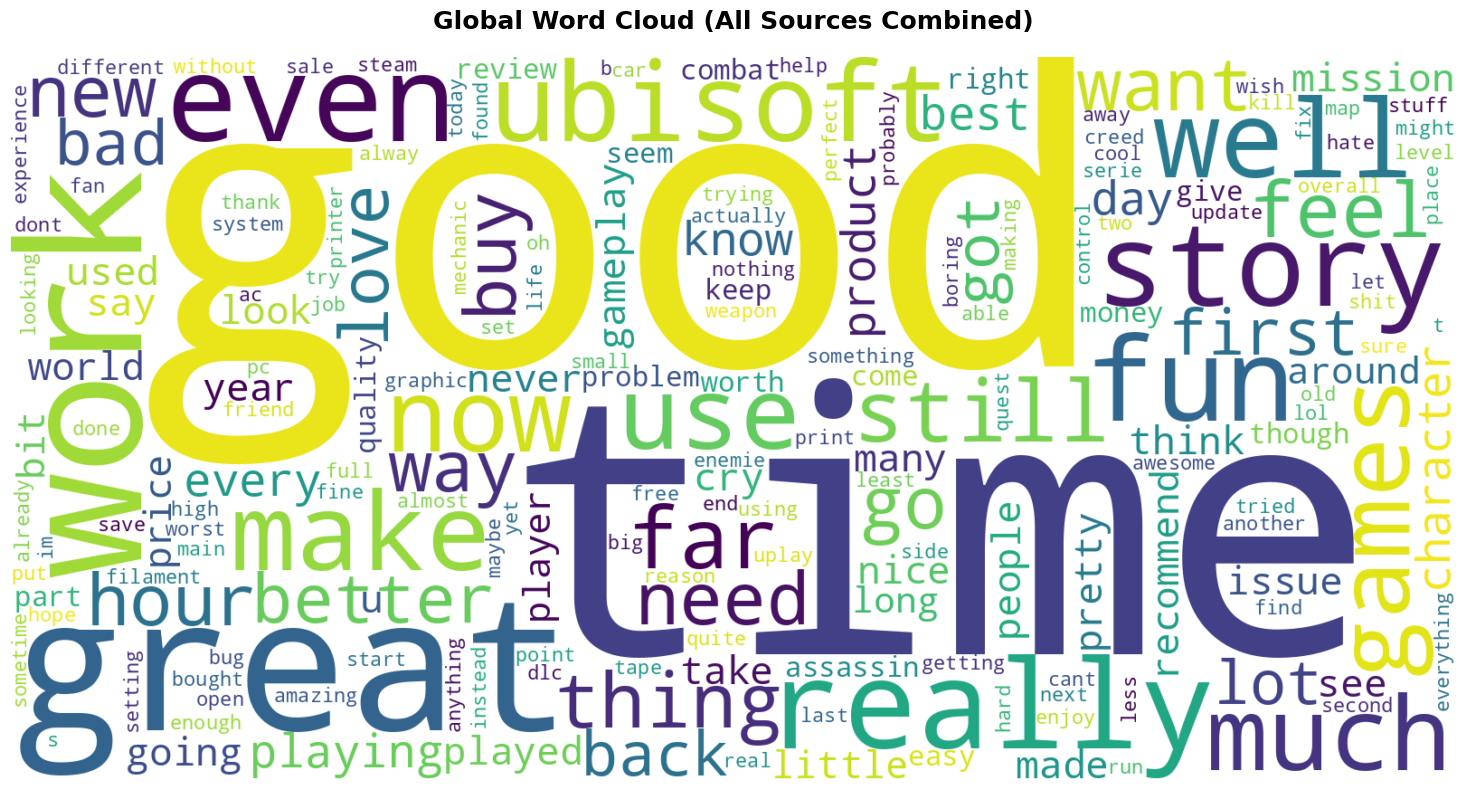

In [13]:
#!pip install wordcloud
from wordcloud import WordCloud, STOPWORDS

# Define the sources to combine
sources = ['twitter', 'steam_ubisoft', 'amazon_reviews', 'social_mixed']

print("Generating Global Word Cloud...")

# List to store all texts
all_texts = []

# Custom stop words to exclude web noise and common verbs
custom_stopwords = set(STOPWORDS)
custom_stopwords.update(['http', 'https', 'com', 'br', 'quot', 'just', 'like', 'game', 'play', 'will', 'one'])

for source in sources:
    filename = f"dataset_{source}.csv"
    try:
        # Load only the 'text' column to save RAM
        df = pd.read_csv(filename, usecols=['text'])
        # Append all text from this source to the global list
        all_texts.append(" ".join(df['text'].dropna().astype(str)))
    except FileNotFoundError:
        print(f"File {filename} not found, skipping.")

# Combine everything into one massive string
global_text = " ".join(all_texts)

if global_text.strip():
    # Generate the Word Cloud
    wordcloud = WordCloud(
        width=1600,
        height=800,
        background_color='white',
        stopwords=custom_stopwords,
        colormap='viridis',
        max_words=200, # Display the top 200 most frequent words
        collocations=False # Avoid duplicating words like "game" and "games"
    ).generate(global_text)

    # Display the Word Cloud
    plt.figure(figsize=(16, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title('Global Word Cloud (All Sources Combined)', fontsize=18, fontweight='bold', pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Error: No text could be loaded.")